In [76]:
#importing libraries
# site scrapping - https://jiji.ng/api_web/v1/listing?slug=cars&page=1&webp=True
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("jiji_car_dataset.csv")

In [77]:
def extract_make_model_year(title):
    clean_title = re.sub(r"^New\s+", "", title, flags=re.IGNORECASE)
    pattern = r"(?P<make>\b[a-zA-Z\-]+)\s+(?P<model>[A-Za-z0-9\-]+(?:\s[A-Za-z0-9\-]+)?)?.*?(?P<year>\d{4})(?!\d)"
    match = re.search(pattern, clean_title)
    if match:
        return match.group("make"), match.group("model"), match.group("year")
    return None, None, None

In [78]:
df[["make", "model", "year"]] = df["title"].apply(
    lambda x: pd.Series(extract_make_model_year(x))
)

In [79]:
def extract_condition(condition):
    condition_lower = condition.lower()
    if "foreign used" in condition_lower:
        return "foreign used"
    elif "local used" in condition_lower:
        return "local used"
    elif "brand new" in condition_lower:
        return "brand new"
    else:
        return None

In [80]:
def extract_transmission(transmission):
    transmission_lower = transmission.lower()
    if "automatic" in transmission_lower:
        return "automatic"
    elif "manual" in transmission_lower:
        return "manual"
    else:
        return None

In [81]:
#communicatting with API
def fetch_data(page):
    url = "https://jiji.ng/api_web/v1/listing"
    params = {
        "slug": "cars",
        "page": page,
        "webp": True
    }

    headers = {
        "User_Agent": "Mozilla/5.0"
    }
    try:
        response = requests.get(url, headers=headers, params=params)
        data = response.json()
    except requests.RequestException:
        print(f"[Page] {page}, Request error")
        return []
    except ValueError:
        print(f"[Page] {page}, Decode error")

    adverts = data.get("adverts_list", {}).get("adverts", [])
    if not isinstance(adverts, list):
        print(f"A error occured, Expected list but got {type(adverts)}")
        return []

    return adverts

In [82]:
def get_attr_value(attrs, key_name):
    for attr in attrs:
        if attr.get("name", "").lower() == key_name.lower():
            return attr.get("value", "").strip()
    return None

In [83]:
# #control function - carries all functionality of the code
# def main():
#     all_ads = []
#     for page in range(1, 101):
#         ads = fetch_data(page)
#         print(f"Page {page}. {len(ads)} ads found.")

#         for ad in ads:
#             if isinstance(ad, dict):
#                 attrs = ad.get("attrs", [])
#                 title = ad.get("title", "")
#                 condition_ = get_attr_value(attrs, "condition")
#                 transmission_ = get_attr_value(attrs, "transmission")
#                 condition = extract_condition(condition_)
#                 transmission = extract_transmission(transmission_)
#                 make, model, year = extract_make_model_year(title)
#                 price = ad.get("price_title", "")

#                 if price:
#                     all_ads.append({
#                         "title": title,
#                         "make": make,
#                         "model": model,
#                         "year": year,
#                         "condition": condition, 
#                         "transmission": transmission,
#                         "price": price
#                     })
#     if all_ads:
#         df = pd.DataFrame(all_ads)
#         df.to_csv("new_jiji_car_dataset.csv", index=False)
#         print("Successfully extracted car dataset from Jiji.")
#     else:
#         print("Ops! Nothing to extract.")

# main()

In [84]:
df.to_csv("new_jiji_car_dataset.csv", index=False)

**DATA CLEANING**

In [85]:
df = pd.read_csv("new_jiji_car_dataset.csv")
df.isnull().sum()

title            0
make            19
model           19
year            19
condition        0
transmission     8
price            0
dtype: int64

In [86]:
df.head()

,title,make,model,year,condition,transmission,price
0,Lexus ES 330 2006,Lexus,ES 330,2006.0,local used,automatic,"₦ 6,500,000"
1,Lexus RX 350 F Sport AWD 2018 Black,Lexus,RX 350,2018.0,local used,automatic,"₦ 31,000,000"
2,New Zeekr 9X 2026 Black,Zeekr,9X,2026.0,brand new,automatic,"₦ 220,000,000"
3,Lexus RX 350 F Sport AWD 2016 Red,Lexus,RX 350,2016.0,foreign used,automatic,"₦ 58,500,000"
4,Lexus RX 350 FWD 2012 Gray,Lexus,RX 350,2012.0,foreign used,automatic,"₦ 20,500,000"


In [87]:
df = df.dropna()
df.isnull().sum()

title           0
make            0
model           0
year            0
condition       0
transmission    0
price           0
dtype: int64

In [88]:
df.info()

<class 'pandas.DataFrame'>
Index: 1971 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1971 non-null   str    
 1   make          1971 non-null   str    
 2   model         1971 non-null   str    
 3   year          1971 non-null   float64
 4   condition     1971 non-null   str    
 5   transmission  1971 non-null   str    
 6   price         1971 non-null   str    
dtypes: float64(1), str(6)
memory usage: 280.1 KB


In [89]:
df["price"] = (
    df["price"]
    .astype(str)
    .replace('[₦,]', "", regex=True)
    .astype(float)
)
df["price"].head()

0      6500000.0
1     31000000.0
2    220000000.0
3     58500000.0
4     20500000.0
Name: price, dtype: float64

In [90]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

detect_outlier = (
    (df["price"] < lower_bound) | (df["price"] > upper_bound)
)
print(detect_outlier.sum())
df = df.loc[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
]
df = df.drop(df[detect_outlier].index)

198


C:\Users\MARYAM\AppData\Local\Temp\ipykernel_13052\485575879.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df.drop(df[detect_outlier].index)


In [91]:
df.reset_index()

,index,title,make,model,year,condition,transmission,price
0,0,Lexus ES 330 2006,Lexus,ES 330,2006.0,local used,automatic,6500000.0
1,1,Lexus RX 350 F Sport AWD 2018 Black,Lexus,RX 350,2018.0,local used,automatic,31000000.0
2,4,Lexus RX 350 FWD 2012 Gray,Lexus,RX 350,2012.0,foreign used,automatic,20500000.0
3,6,Toyota 4-Runner SR5 V8 4x4 2005 Blue,Toyota,4-Runner SR5,2005.0,local used,automatic,5800000.0
4,7,Toyota Sienna 2003 Green,Toyota,Sienna,2003.0,local used,automatic,5000000.0
...,...,...,...,...,...,...,...,...
1768,1993,Toyota Camry LE (2.5L 4cyl 8A) 2019 Silver,Toyota,Camry LE,2019.0,foreign used,automatic,21500000.0
1769,1994,Toyota Camry L FWD (2.5L 4cyl 8AM) 2018 Silver,Toyota,Camry L,2018.0,foreign used,automatic,27800000.0
1770,1995,Mercedes-Benz B-Class 2009 Gray,Mercedes-Benz,B-Class,2009.0,foreign used,automatic,7000000.0
1771,1996,Lexus ES 350 2010 Silver,Lexus,ES 350,2010.0,foreign used,automatic,10800000.0


In [92]:
print(df["price"].min())
print(df["price"].max())

1850000.0
36000000.0


In [93]:
df["year"].unique()

array([2006., 2018., 2012., 2005., 2003., 2014., 2008., 2011., 2020.,
       2013., 2009., 2016., 2015., 2019., 2004., 2024., 2007., 2010.,
       2000., 2025., 2021., 2017., 2001., 1998., 2002., 1999., 2022.,
       2023.])

In [94]:
df["make"] = (df["make"].replace("-", " ", regex=True))
df["condition"] = (df["condition"].str.title())
df["transmission"] = (df["transmission"].str.title())
df["year"] = (
    df["year"]
    .astype(float)
    .astype(int)
)
df.head()

,title,make,model,year,condition,transmission,price
0,Lexus ES 330 2006,Lexus,ES 330,2006,Local Used,Automatic,6500000.0
1,Lexus RX 350 F Sport AWD 2018 Black,Lexus,RX 350,2018,Local Used,Automatic,31000000.0
4,Lexus RX 350 FWD 2012 Gray,Lexus,RX 350,2012,Foreign Used,Automatic,20500000.0
6,Toyota 4-Runner SR5 V8 4x4 2005 Blue,Toyota,4-Runner SR5,2005,Local Used,Automatic,5800000.0
7,Toyota Sienna 2003 Green,Toyota,Sienna,2003,Local Used,Automatic,5000000.0


In [95]:
df.info()

<class 'pandas.DataFrame'>
Index: 1773 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1773 non-null   str    
 1   make          1773 non-null   str    
 2   model         1773 non-null   str    
 3   year          1773 non-null   int64  
 4   condition     1773 non-null   str    
 5   transmission  1773 non-null   str    
 6   price         1773 non-null   float64
dtypes: float64(1), int64(1), str(5)
memory usage: 227.3 KB


In [96]:
df = df.to_csv("cleaned_jiji_car_dataset.csv", index=False)

**EDA - DATA ANALYSIS & VISUALIZATION**

In [97]:
#What are the most common car brands (make)? - Frequency count of each brand.
df = pd.read_csv("cleaned_jiji_car_dataset.csv")
df["make"].value_counts()

make
Toyota           728
Lexus            223
Honda            211
Acura            184
Mercedes Benz    167
Hyundai           73
BMW               35
Peugeot           30
Ford              22
Kia               13
Pontiac           13
Nissan            13
Chevrolet         11
Mazda             10
Land              10
Volkswagen        10
Mitsubishi         3
Jaguar             2
Audi               2
Mini               2
Dodge              2
Forthing           1
Changan            1
Renault            1
Dongfeng           1
Jetour             1
Chrysler           1
Infiniti           1
Volvo              1
Rover              1
Name: count, dtype: int64

In [98]:
df.groupby("make")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

make
Forthing         36,000,000
Jetour           35,000,000
Dongfeng         27,500,000
Dodge            23,500,000
Mini             18,250,000
Land             17,768,125
Rover            17,500,000
Changan          16,500,000
Mercedes Benz    16,322,363
Lexus            15,459,964
Toyota           14,265,381
Volvo            14,000,000
Volkswagen       13,270,000
Ford             12,935,795
Mazda            12,775,000
Acura            12,246,929
Hyundai          12,186,575
Mitsubishi       12,166,666
Chevrolet        12,120,028
Jaguar           12,000,000
BMW              11,869,714
Audi             11,200,000
Honda            10,735,638
Nissan            9,457,692
Chrysler          8,500,000
Pontiac           7,184,615
Kia               6,880,769
Peugeot           5,043,698
Renault           4,000,000
Infiniti          3,700,000
Name: price, dtype: str

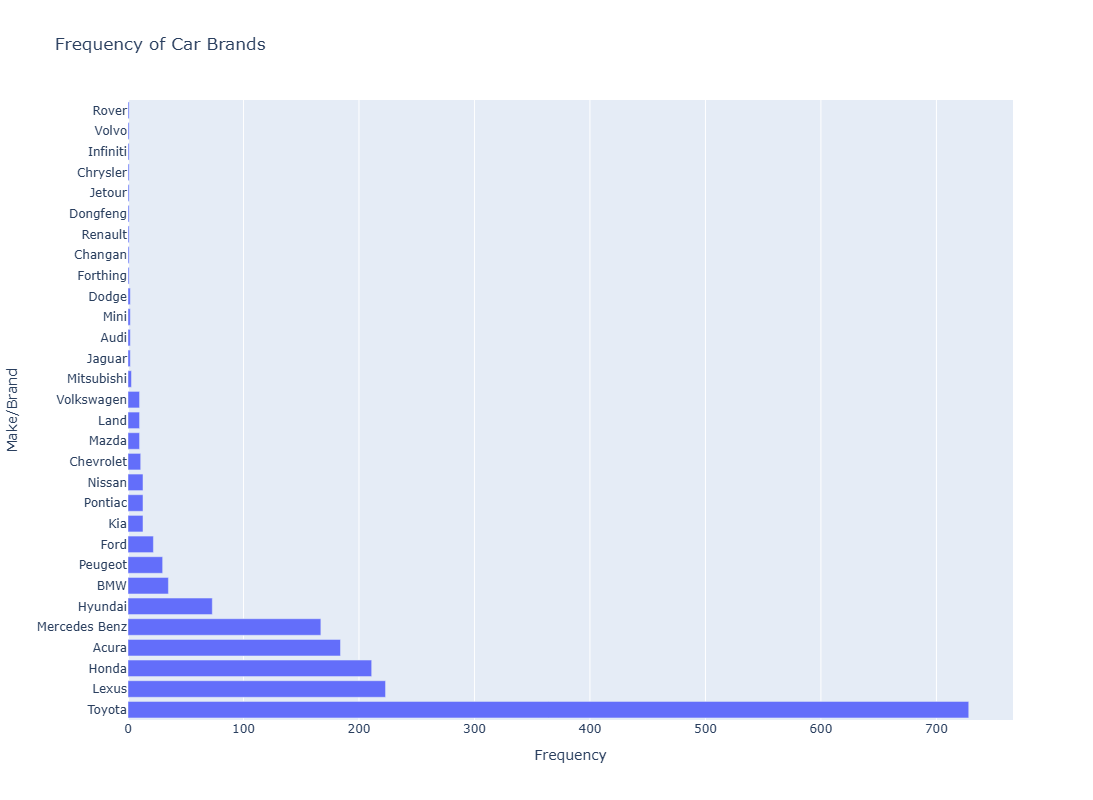

In [99]:
#Visualize with a bar chart
make_counts = df["make"].value_counts()
fig1 = px.bar(
    x = make_counts.values,
    y = make_counts.index,
    title = "Frequency of Car Brands"
)
fig1.update_layout(
    xaxis_title="Frequency",
    yaxis_title= "Make/Brand",
    height=800
)

fig1.show()

In [100]:
#most common models per brand
df.groupby("make")["model"].value_counts()

make        model         
Acura       MDX               81
            MDX Technology    35
            MDX Advance       28
            MDX SUV           16
            MDX w              6
                              ..
Volkswagen  Touareg            1
            Caddy              1
            E-Golf             1
            Beetle 2           1
Volvo       XC90 3             1
Name: count, Length: 298, dtype: int64

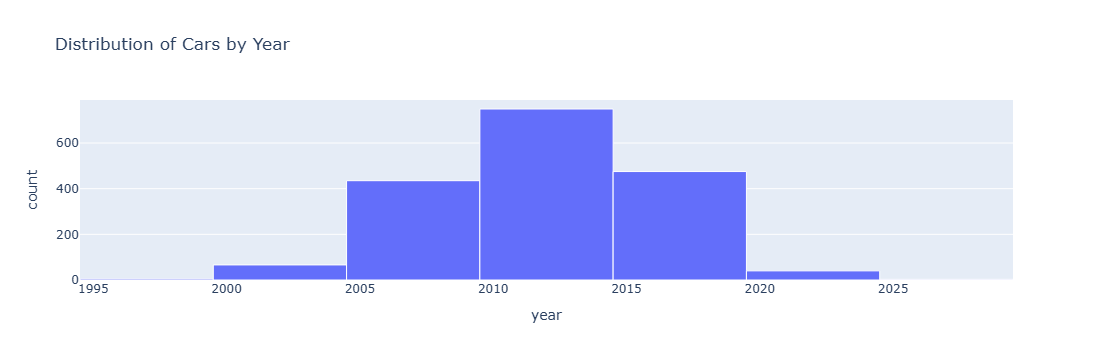

In [101]:
#Histogram of year shows age distribution of listed cars.
fig2 = px.histogram(
    df,
    x="year",
    nbins=8,
    title="Distribution of Cars by Year"
)
fig2.update_traces(
    marker_line_color="white",
    marker_line_width=1
)
fig2.show()

In [102]:
#Compare mean/median price by make and model.
df.groupby(['make', 'model'])['price'].agg(['mean', 'median']).sort_values(ascending=False, by="make").map('{:,.0f}'.format)

mean      median
make       model                                 
Volvo      XC90 3          14,000,000  14,000,000
Volkswagen Beetle 2        15,500,000  15,500,000
           Caddy            8,300,000   8,300,000
           E-Golf          25,000,000  25,000,000
           Jetta            8,600,000   8,600,000
...                               ...         ...
Acura      MDX Technology  10,365,714  10,500,000
           MDX w           21,916,667  23,000,000
           RDX             13,000,000  13,000,000
           TL SH-AWD       12,500,000  12,500,000
           ZDX Base        16,491,667  17,250,000

[298 rows x 2 columns]

In [103]:
#Compare “Foreign Used” vs “Local Used” prices
df.groupby("condition")["price"].mean().map('{:,.0f}'.format)

condition
Brand New       36,000,000
Foreign Used    16,273,642
Local Used       8,927,695
Name: price, dtype: str

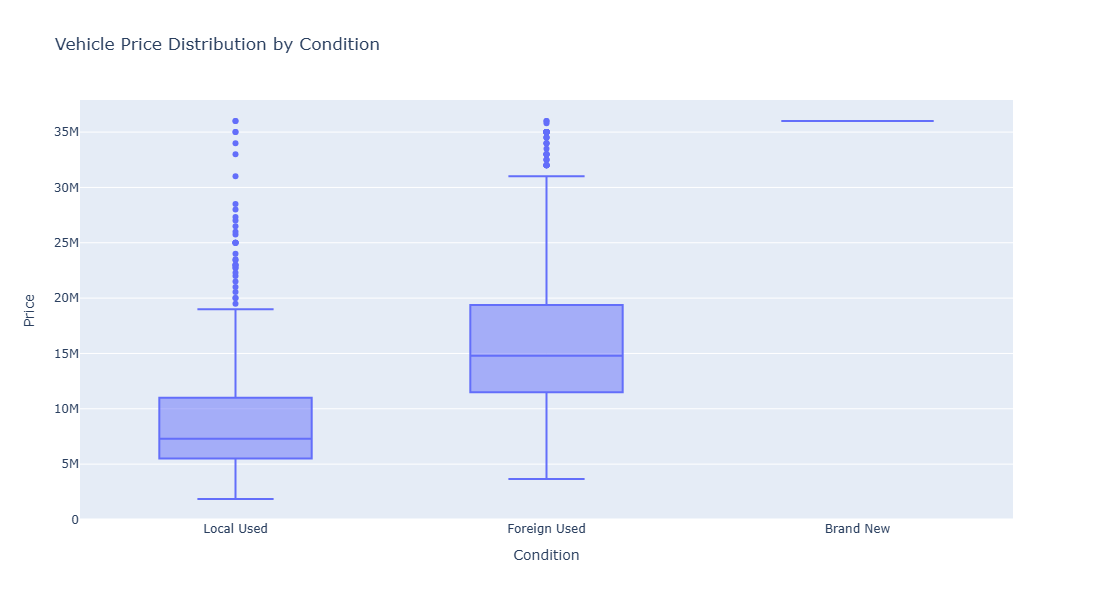

In [104]:
#Boxplot for visual insight
fig3 = px.box(
    df,
    x="condition",
    y="price",
    title="Vehicle Price Distribution by Condition",
    labels={
        "condition": "Condition",
        "price": "Price"
    }
)

fig3.update_layout(
    width=1000,
    height=600
)

fig3.show()

In [105]:
#Compare “Automatic” vs “Manual”.
df.groupby("transmission")["price"].mean().map('{:,.0f}'.format)

transmission
Automatic    13,626,951
Manual        7,150,000
Name: price, dtype: str

In [106]:
#Correlation coefficient between year and price.
df.groupby("year")["price"].mean().map('{:,.0f}'.format)

year
1998     3,433,333
1999     3,200,000
2000     4,911,111
2001     3,400,000
2002     4,028,571
2003     5,224,700
2004     4,707,669
2005     6,688,108
2006     6,732,931
2007     7,569,819
2008     8,047,385
2009     9,151,613
2010    10,162,893
2011    11,935,777
2012    13,326,679
2013    14,010,425
2014    15,699,181
2015    17,761,987
2016    18,804,095
2017    19,421,558
2018    23,698,704
2019    23,601,515
2020    26,650,000
2021    26,771,429
2022    30,375,000
2023    14,350,000
2024    28,233,333
2025    13,950,000
Name: price, dtype: str

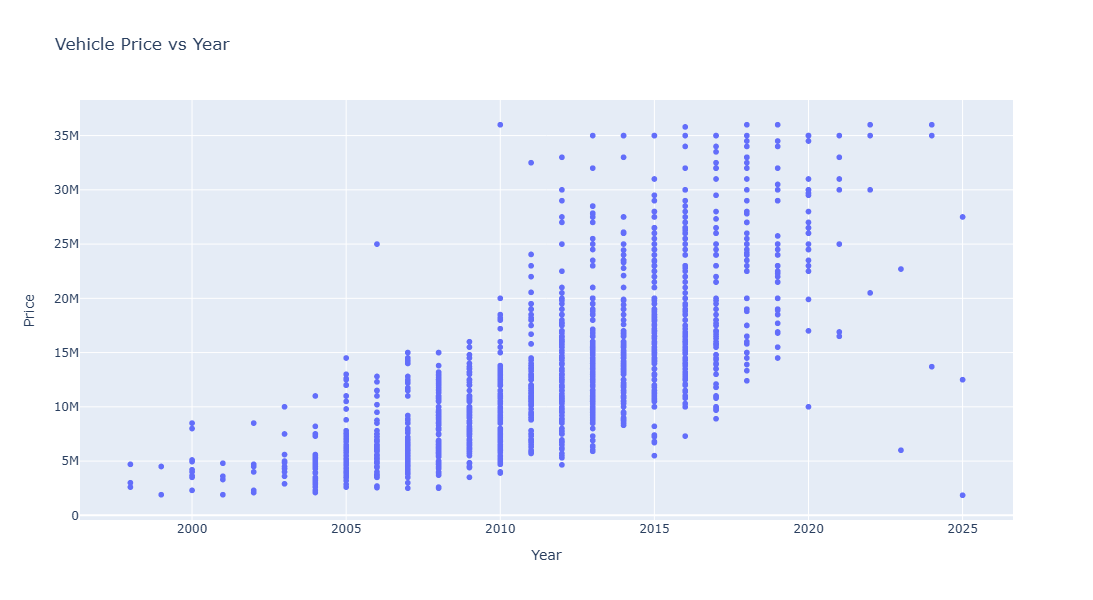

In [107]:
#Scatterplot of year vs price.
fig4 = px.scatter(
    df,
    x="year",
    y="price",
    title="Vehicle Price vs Year",
    labels={
        "year": "Year",
        "price": "Price"
    },
    width=800,
    height=600
)


fig4.show()

**Insight Questions**

* Which brands dominate the higher price range, do Lexus, Mercedes-Benz, and Toyota consistently appear among the top?
  
Lexus, Mercedes-Benz and Toyota do appear strongly in the dataset, but they do not all dominate the very highest price range. **Mercedes-Benz** has the highest average price of the three, followed by Lexus and then Toyota. **Toyota's importance is particularly evident** from frequency: it has **814** listings, compared with **Lexus (267)** and **Mercedes-Benz (208)**. Thus, Toyota dominated by market presence, while Mercedes-Benz and Lexus occupy a higher average price position.

* Do Foreign Used cars generally cost more than Local Used ones?
  
Foreign Used vehicles cost approximately **2.3 times the average price of Local Used vehicles** in this dataset. This is one of the strongest patterns in the analysis and suggests that vehicle condition/source is an important pricing factor.

* How strongly does year correlate with price, does price clearly drop for older vehicles?

The analysis shows a **strong positive relationship** between vehicle year and price.** Older vehicles** generally have **lower prices**, while **newer vehicles** command substantially **higher prices**. There are some fluctuations; for example, the average falls from 2022 to 2024, but the overall trend is strongly upward. 


* Are automatic cars listed more frequently and at higher prices than manual ones?

Automatic cars are both more expensive on average and, from the dataset structure, appear to be the dominant transmission type. Automatic vehicles therefore have an average listed price about **62% higher than manual vehicles**. 


* Which models retain value better, for instance, how do Toyota Hilux and Lexus RX 350 compare with Honda Accord?

The dataset contains multiple Lexus RX 350 listings across different years and conditions—for example, a 2016 Foreign Used RX 350 is listed at ₦58.5M, while a 2012 Foreign Used RX 350 is ₦20.5M. This illustrates the importance of year and condition when evaluating value retention. 

**Report Summary**

The dataset contains **1,971 cleaned car listings**, with **Toyota** dominating market presence with **814 listings,** followed by Lexus and Mercedes-Benz. Mercedes-Benz and Lexus command higher average prices than Toyota, although luxury brands such as Bentley and Zeekr occupy the extreme upper price range. Foreign Used vehicles average **₦22.99M** compared with **₦10.03M** for Local Used vehicles, making Foreign Used the higher-value used-car channel. Vehicle year has a **strong positive relationship with price**, with newer vehicles generally commanding substantially higher prices than older vehicles. **Automatic cars are more prevalent** and have a higher average price (**₦19.57M vs ₦12.09M**) than manual cars.


By overall market presence, **Toyota** is the strongest brand in the dataset, while the most listed model is **Acura MDX** with **81 listings**. The strongest improvement strategy is to focus on high-demand Toyota/Lexus inventory while strengthening Local Used listings through better vehicle quality, documentation, pricing and presentation. **Increase visibility and competitive pricing for Local Used cars**, **prioritize newer/high-demand models**, emphasize verified vehicle condition/history, and use the strong Toyota/Lexus demand as a benchmark for inventory and marketing decisions. 
